In [ ]:
import pandas as pd
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [ ]:
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


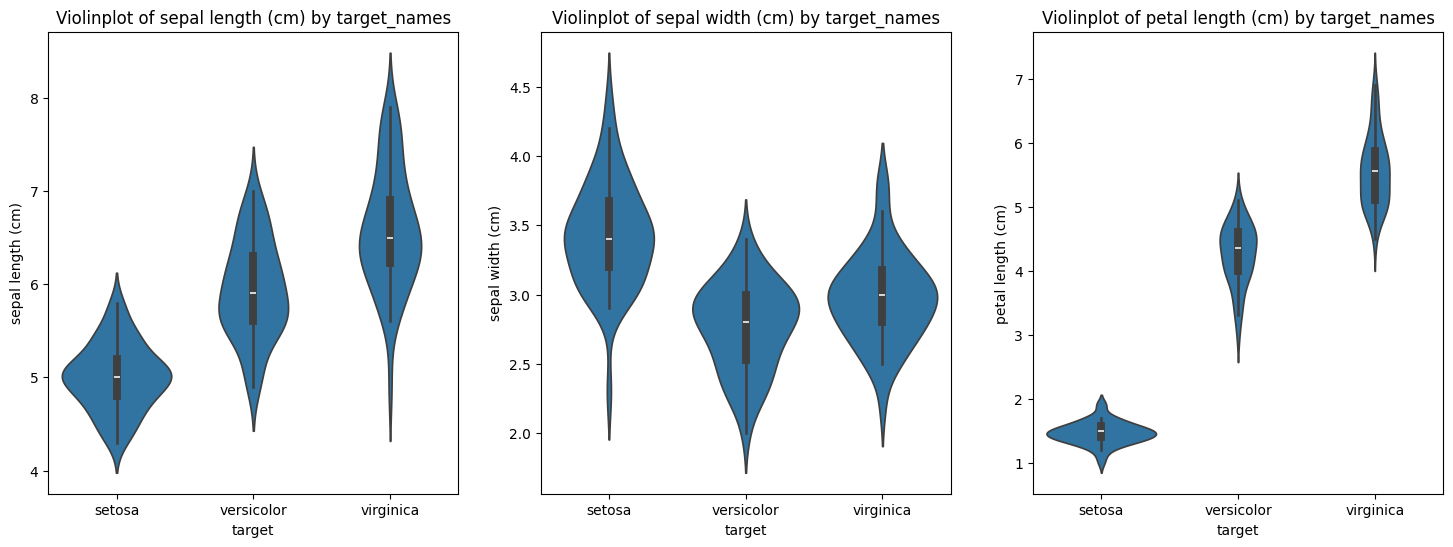

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Iterate through each numerical column
for i, column in enumerate(df.iloc[:,0:3]):
    # Create a violinplot for each target_names value
    sns.violinplot(x="target", y=column, data=df, ax=axes[i])
    axes[i].set_title(f"Violinplot of {column} by target_names")

# Show the plot
plt.show()

In [ ]:
setosa      =df[df['target']=='setosa']
versicolor  =df[df['target']=='versicolor']
virginica   =df[df['target']=='virginica']

#t-Test:
H0 = The means are equal.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

**Chat,**
1. What do I need to check before running a t-test? Make sure to mention normal distributions and equal variances.
2. What's the difference between paired and independent t-tests? **When** should I use which?

Related - - same flower

In [ ]:
stats.ttest_rel(setosa['sepal length (cm)'], setosa['sepal width (cm)'])

TtestResult(statistic=np.float64(42.32339235217487), pvalue=np.float64(3.0231710793686155e-40), df=np.int64(49))

independent

In [ ]:
stats.ttest_ind(setosa['sepal length (cm)'], versicolor['sepal length (cm)'])

TtestResult(statistic=np.float64(-10.52098626754911), pvalue=np.float64(8.985235037487079e-18), df=np.float64(98.0))

### Same Variance?

In [ ]:
(setosa['sepal length (cm)'].std(), versicolor['sepal length (cm)'].std(), virginica['sepal length (cm)'].std())

(0.3524896872134512, 0.5161711470638635, 0.635879593274432)

In [ ]:
stats.bartlett(setosa['sepal length (cm)'], versicolor['sepal length (cm)'])

BartlettResult(statistic=np.float64(6.891726740802407), pvalue=np.float64(0.008659557933880048))

###Normal?
  - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html
  - https://www.itl.nist.gov/div898/handbook/eda/section3/normprpl.htm
  - Q-Q vs Probablity plots:
    - https://www.itl.nist.gov/div898/handbook/eda/section3/qqplot.htm
    - https://fr.mathworks.com/help/stats/distribution-plots.html
    - https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.ProbPlot.html

**Chat**,
1. What's the difference between Q-Q plots and probability plots? Check the link above before answering and make sure to mention the qqplot and probplot functions and scaled/unscaled quantiles.
3. Walk me through an example in python using `statsmodels.api.ProbPlot`.
    

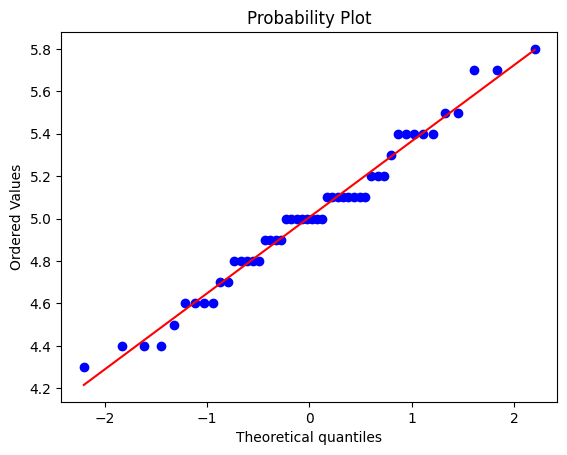

In [ ]:
stats.probplot(setosa['sepal length (cm)'], dist="norm", plot=plt);

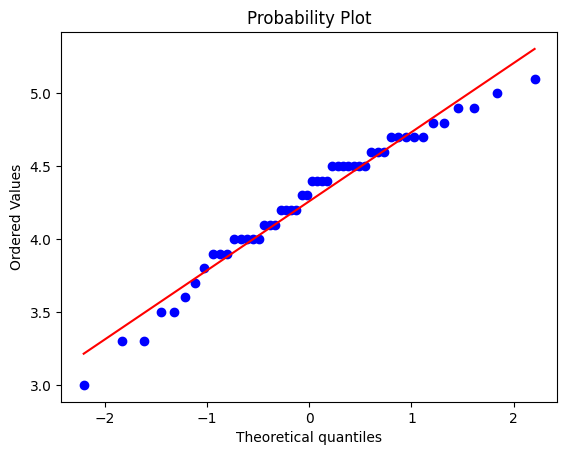

In [ ]:
stats.probplot(versicolor['petal length (cm)'], dist="norm", plot=plt);

### Normality tests
  - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html#scipy.stats.shapiro
  
    You want high p values, but be careful (read above).
  - https://en.wikipedia.org/wiki/Normality_test


**Chat**,
  1. Explain H0 in the Shapiro–Wilk test.
  2. What does a high p value mean in this context?
  3. Does it mean my data is normal? What else can lead to a high p-value?

In [ ]:
stats.shapiro(setosa['sepal length (cm)'])

ShapiroResult(statistic=np.float64(0.977698549796646), pvalue=np.float64(0.4595131499174534))

In [ ]:
stats.shapiro(versicolor['petal length (cm)'])

ShapiroResult(statistic=np.float64(0.96600440254332), pvalue=np.float64(0.15847783815657573))

#Non-parametric alternative to t-test?

- https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test
- https://en.wikipedia.org/wiki/Wilcoxon_signed-rank_test

**Chat**,
1. Explain non parametric stats. Give me a simple example. Discuss the pros and cons.
2. How do you calculate the distribution of the T-statistic in Wilcoxon's signed-rank test? Discuss both the brute force and more efficient approaches.

In [ ]:
stats.mannwhitneyu(setosa['sepal length (cm)'], versicolor['sepal width (cm)'])

MannwhitneyuResult(statistic=np.float64(2500.0), pvalue=np.float64(6.360688867645826e-18))

In [ ]:
stats.wilcoxon(setosa['sepal length (cm)'], setosa['sepal width (cm)'])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(7.402862078244635e-10))

# Same distribution?
### Empirical CDF
  - https://en.wikipedia.org/wiki/Empirical_distribution_function


**Chat**, What is the empirical CDF good for?


/tmp/ipykernel_411/3879277393.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


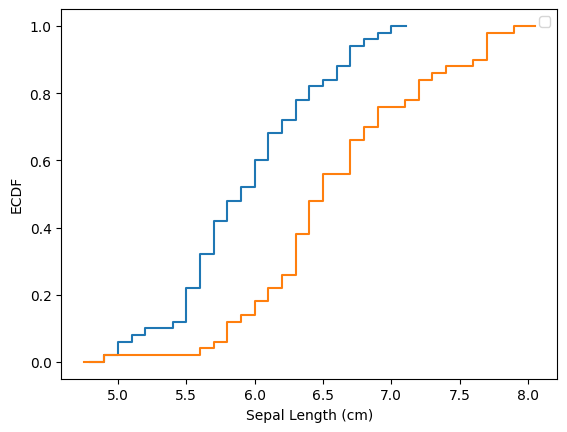

In [ ]:
versicolor_ecdf = stats.ecdf(versicolor['sepal length (cm)'])
versicolor_ecdf.cdf.plot(plt)


virginica_ecdf = stats.ecdf(virginica['sepal length (cm)'])
virginica_ecdf.cdf.plot(plt)
plt.xlabel(r'Sepal Length (cm)')
plt.ylabel('ECDF')
plt.legend()

/tmp/ipykernel_411/1651175260.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


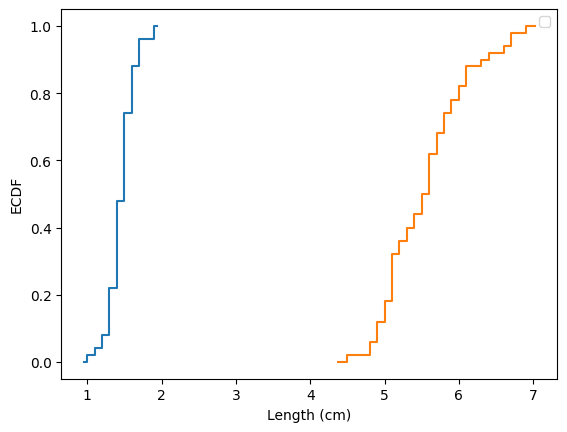

In [ ]:
versicolor_ecdf = stats.ecdf(setosa['petal length (cm)'])
versicolor_ecdf.cdf.plot(plt)


virginica_ecdf = stats.ecdf(virginica['petal length (cm)'])
virginica_ecdf.cdf.plot(plt)
plt.xlabel(r'Length (cm)')
plt.ylabel('ECDF')
plt.legend()

# KS test
  - https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
  - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html

**Chat**,
1. Explain the importance of the Glivenko–Cantelli theorem and walk me step by step through the proof, it's here on wiki:
https://en.wikipedia.org/wiki/Glivenko%E2%80%93Cantelli_theorem#Proof
2. What's H0 of the one sample KS test?
3. How do we calculate the distribution of the KS test statistic?

In [ ]:
stats.ks_2samp(['sepal length (cm)'], virginica['sepal length (cm)'])setosa

KstestResult(statistic=np.float64(0.92), pvalue=np.float64(7.773164323782225e-23), statistic_location=np.float64(5.5), statistic_sign=np.int8(1))

In [ ]:
stats.ks_2samp(setosa['petal length (cm)'], virginica['petal length (cm)'],alternative="greater")

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(9.911653021418333e-30), statistic_location=np.float64(1.9), statistic_sign=np.int8(1))

#ANOVA
~(multidimensional t-test)
 - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
 - https://en.wikipedia.org/wiki/One-way_analysis_of_variance


 **Chat**,
 1. What's H0 of a one way ANOVA? What are the assumptions of the test?
 2. What should I do after I reject H0?
 3. Why are there entire university courses on ANOVA when it's just an F-test?
 4. What's an F-test anyway?

In [ ]:
stats.f_oneway(setosa['sepal length (cm)'], versicolor['sepal length (cm)'], virginica['sepal length (cm)'])

F_onewayResult(statistic=np.float64(119.26450218450468), pvalue=np.float64(1.6696691907693826e-31))

# Violated assumptions?
Use a non parametric test.

In [ ]:
stats.kruskal(setosa['sepal length (cm)'], versicolor['sepal length (cm)'], virginica['sepal length (cm)'])

KruskalResult(statistic=np.float64(96.93743600064833), pvalue=np.float64(8.91873433246198e-22))

# Contingency Tests
 - https://en.wikipedia.org/wiki/Lady_tasting_tea
 - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisher_exact.html
 - https://en.wikipedia.org/wiki/Odds_ratio

**Chat**,
1. What's the test statistic in Fishers exact test? How do we calculate the p-val?
1. Explain why the marginals in Fishers exact test are fixed. Give real world examples in which this assumption makes sense and ones in which it's questionable.
2. When should I prefer another test over Fisher's exact? Which ones?

####Case 1: The lady guesses randomly



In [ ]:
n_trails = 10
milk_added_first = np.random.permutation([False]*n_trails + [True]* n_trails)
lady_said        = np.random.permutation([False]*n_trails + [True]* n_trails)
df = pd.DataFrame({'milk_added_first': milk_added_first, 'lady_said': lady_said})
df

,milk_added_first,lady_said
0,False,False
1,False,True
2,True,False
3,True,False
4,True,True
5,False,False
6,True,True
7,False,False
8,True,True
9,False,True


In [ ]:
ctab = pd.crosstab(df['milk_added_first'], df['lady_said'])
ctab

lady_said,False,True
milk_added_first,,
False,1020,980
True,980,1020


In [ ]:
stats.fisher_exact(ctab)

SignificanceResult(statistic=np.float64(1.083298625572678), pvalue=np.float64(0.21746325031508507))

####Case 2: The lady is correct 90% of the time

In [ ]:
n_trials = 1000
guesses = int(0.05*n_trials)
milk_added_first = np.random.permutation([False]*n_trials + [True]* n_trials)
lady_said        = np.random.permutation([False]*guesses + [True]*guesses)
lady_said        = np.concatenate([lady_said, milk_added_first[2*guesses:]])
df = pd.DataFrame({'milk_added_first': milk_added_first, 'lady_said': lady_said})
df

,milk_added_first,lady_said
0,True,True
1,True,False
2,True,False
3,False,False
4,True,False
...,...,...
1995,True,True
1996,True,True
1997,True,True
1998,True,True


In [ ]:
ctab = pd.crosstab(df['milk_added_first'], df['lady_said'])
ctab

lady_said,False,True
milk_added_first,,
False,973,27
True,24,976


In [ ]:
stats.fisher_exact(ctab)

SignificanceResult(statistic=np.float64(1465.5061728395062), pvalue=np.float64(0.0))

H0: odds ratio = 1

**Chat**, what's an odds ratio?

# Chi^2
**Chat**,
1. What are the assumptions of the chi squared test? What happens when they're violated?
2. What's H0 of the test?

In [ ]:
stats.chi2_contingency(ctab)

Chi2ContingencyResult(statistic=np.float64(1805.001805001805), pvalue=np.float64(0.0), dof=1, expected_freq=array([[500.5, 499.5],
       [500.5, 499.5]]))

(1797, 64)


<Figure size 640x480 with 0 Axes>

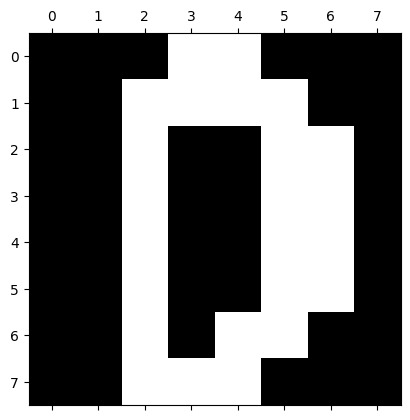

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)
import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[0]>5)
plt.show()

In [ ]:
df = pd.DataFrame(digits.data>7)
df["target"] = digits.target
df

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,0
1,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,1
2,False,False,False,False,True,True,False,False,False,False,...,False,False,False,False,False,True,True,True,False,2
3,False,False,False,True,True,False,False,False,False,True,...,False,False,False,False,True,True,True,False,False,3
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,9
1793,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,True,True,False,False,False,0
1794,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,8
1795,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,9


In [ ]:
ctab = pd.crosstab(df.iloc[:,4],df["target"])
ctab

target,0,1,2,3,4,5,6,7,8,9
4,,,,,,,,,,
False,24,42,63,4,31,4,62,7,17,31
True,154,140,114,179,150,178,119,172,157,149


In [ ]:
results = stats.chi2_contingency(ctab)
results

Chi2ContingencyResult(statistic=np.float64(180.9555608144271), pvalue=np.float64(3.2002885505305896e-34), dof=9, expected_freq=array([[ 28.23038397,  28.86477462,  28.07178631,  29.02337229,
         28.70617696,  28.86477462,  28.70617696,  28.38898164,
         27.59599332,  28.5475793 ],
       [149.76961603, 153.13522538, 148.92821369, 153.97662771,
        152.29382304, 153.13522538, 152.29382304, 150.61101836,
        146.40400668, 151.4524207 ]]))

In [ ]:
pd.DataFrame(results.expected_freq)

,0,1,2,3,4,5,6,7,8,9
0,28.230384,28.864775,28.071786,29.023372,28.706177,28.864775,28.706177,28.388982,27.595993,28.547579
1,149.769616,153.135225,148.928214,153.976628,152.293823,153.135225,152.293823,150.611018,146.404007,151.452421


#Confidence Intervals
 - https://seeing-theory.brown.edu/frequentist-inference/index.html#section2

**Chat**,
1. What are confidence intervals and confidence levels?
2. What's the relation between confidence levels and p-vals?
3. How do I calculate a parametric CI? Make sure to mention the normal and t distributions. What are the underlying assumptions?


In [ ]:
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


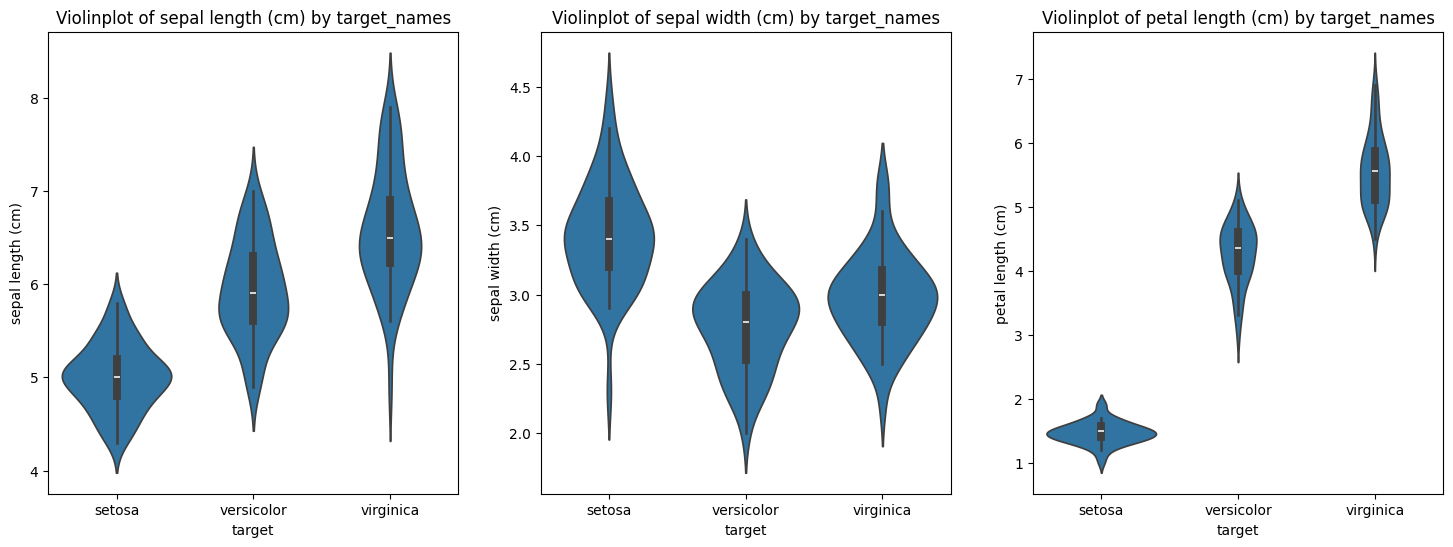

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Iterate through each numerical column
for i, column in enumerate(df.iloc[:,0:3]):
    # Create a violinplot for each target_names value
    sns.violinplot(x="target", y=column, data=df, ax=axes[i])
    axes[i].set_title(f"Violinplot of {column} by target_names")

# Show the plot
plt.show()

In [ ]:
c_level = 0.95
mean = df['sepal length (cm)'].mean()
std  = df['sepal length (cm)'].std()
n    = len(df['sepal length (cm)'])
stats.norm.interval(c_level, loc=mean, scale=std/n**0.5)

(np.float64(5.710817588579892), np.float64(5.9758490780867755))

In [ ]:
stats.t.interval(c_level, df=n-1, loc=mean, scale=std/n**0.5)

(np.float64(5.709732481507366), np.float64(5.976934185159301))


# Bootstrap
- https://seeing-theory.brown.edu/frequentist-inference/index.html#section3
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html
- https://en.wikipedia.org/wiki/Bootstrapping_(statistics)

**Chat**,
1. Explain the expression "pull oneself up by one's bootstraps". Is there something similar in Hebrew?
2. Explain how the bootstrap method works. Make sure to mention sampling from the ECDF. Compare it to regular parameter estimation.
3. How do you calculate CIs with the bootstrap?

In [ ]:
statistic = lambda x : x.mean()
res = stats.bootstrap([df['petal length (cm)']], statistic, confidence_level=0.9)
res.confidence_interval

ConfidenceInterval(low=np.float64(3.519333333333333), high=np.float64(3.9880000000000004))

#False Discovery Rate
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html
- https://xkcd.com/882/
- https://en.wikipedia.org/wiki/Preregistration_(science)


**Chat**,
1. Explain XKCD 882, that's the one with multiple tests and jelly beans.
2. What's p-hacking?
2. Explain the reproducability problem in science.
3. What's the false discovery rate?
4. Comapre Bonferroni's Correction to the Benjamini-Hochberg procedure.